# 💳 Fraud Detection — Stage 1: Exploratory Data Analysis

This project tackles **credit card fraud detection**: given an anonymized
transaction, predict whether it's fraudulent.

The defining challenge here isn't the modeling technique — it's the **class
imbalance**. Fraud is rare by nature (that's what makes it fraud and not just
normal behavior), so the dataset will be overwhelmingly "legit" transactions
with a tiny sliver of fraud. This breaks a lot of default assumptions:
accuracy becomes a useless metric (predicting "not fraud" for everything
would score >99%), and most models will need extra help to even notice the
minority class exists.

Steps in this notebook:
1. Load the data and check its shape/types
2. Quantify the class imbalance
3. Look at `Time` and `Amount` — the only two human-readable features
4. Explore the anonymized `V1`–`V28` features and how they differ by class
5. Check for missing values and duplicates
6. Summarize takeaways that will shape modeling choices in later stages

## 1. Load the data

This dataset (`mlg-ulb/creditcardfraud` on Kaggle) contains transactions made
by European cardholders over two days in September 2013. For privacy reasons,
most of the original features were transformed with **PCA** (Principal
Component Analysis) into 28 anonymized components, `V1` through `V28`. We
don't know what they originally measured — only that they capture some
transformed signal from the real transaction data.

The only features left in their original form are:
- `Time`: seconds elapsed since the first transaction in the dataset
- `Amount`: transaction amount
- `Class`: the label we want to predict (1 = fraud, 0 = legitimate)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

284,807 transactions, 31 columns, all numeric, no missing values reported by
`.info()` — we'll confirm that explicitly below. This is a clean dataset; the
real difficulty is entirely in the class balance and the anonymized features.

## 2. Quantify the class imbalance

This is the single most important fact about this dataset — everything else
we do downstream (metric choice, resampling, model selection) is a response
to this number.

Counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Percentages:
 Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


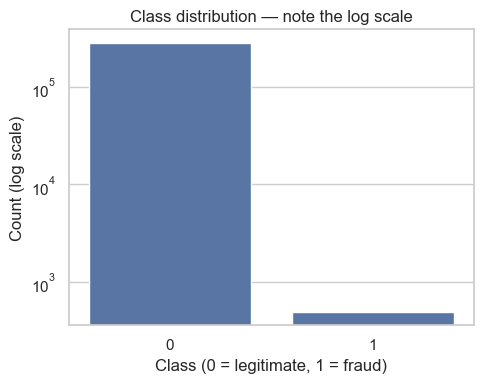

In [3]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print("Counts:\n", class_counts)
print("\nPercentages:\n", class_pct.round(4))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Class (0 = legitimate, 1 = fraud)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Class distribution — note the log scale")
plt.tight_layout()
plt.savefig("../reports/figures/class_distribution.png", dpi=150)
plt.show()

Only **492 of 284,807 transactions (0.17%)** are fraud. The bar chart needs a
log y-axis just to make the fraud bar visible at all — on a linear scale it
would look like zero.

**Why this matters for later stages:**
- A model that always predicts "legitimate" gets 99.83% accuracy while being
  completely useless. We'll need metrics like **precision, recall, F1, and
  ROC-AUC / PR-AUC** instead of accuracy.
- Many classifiers implicitly optimize for overall accuracy and will learn to
  mostly ignore the minority class unless we intervene — via class weights,
  resampling (SMOTE, undersampling), or threshold tuning. That's the focus of
  Stage 3 (`03_resampling.ipynb`).

## 3. `Time` and `Amount` — the human-readable features

These are the only two columns we can interpret directly, so they're worth
looking at closely before diving into the anonymized `V` features.

In [4]:
df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


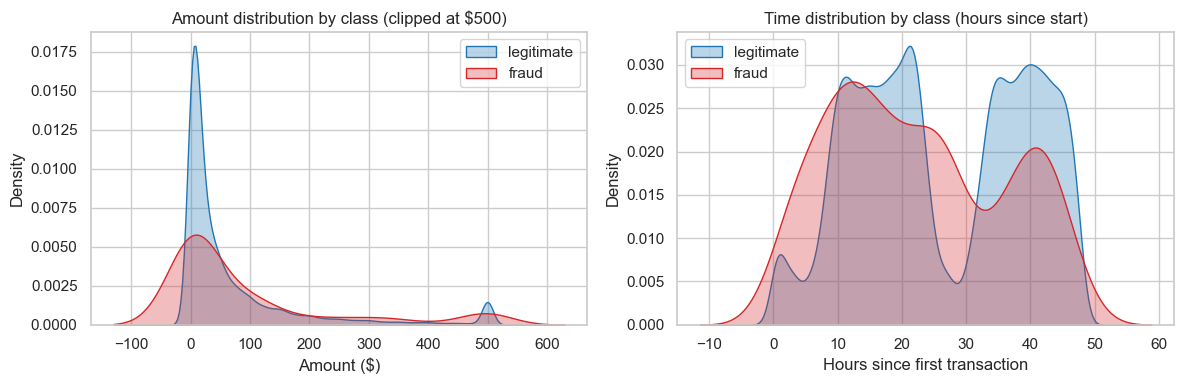

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, label, color in [(0, "legitimate", "tab:blue"), (1, "fraud", "tab:red")]:
    sns.kdeplot(
        df.loc[df["Class"] == cls, "Amount"].clip(upper=500),
        ax=axes[0], label=label, color=color, fill=True, alpha=0.3,
    )
axes[0].set_title("Amount distribution by class (clipped at $500)")
axes[0].set_xlabel("Amount ($)")
axes[0].legend()

for cls, label, color in [(0, "legitimate", "tab:blue"), (1, "fraud", "tab:red")]:
    sns.kdeplot(
        df.loc[df["Class"] == cls, "Time"] / 3600,
        ax=axes[1], label=label, color=color, fill=True, alpha=0.3,
    )
axes[1].set_title("Time distribution by class (hours since start)")
axes[1].set_xlabel("Hours since first transaction")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/time_amount_by_class.png", dpi=150)
plt.show()

In [6]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


**Amount:** fraudulent transactions tend to skew toward smaller amounts on
average, but the spread is wide — there's no single "fraud amount" threshold
that would separate the classes cleanly. `Amount` alone won't be a strong
signal but may still contribute in combination with other features.

**Time:** spans about 48 hours (172,792 seconds), confirming this is two days
of transactions. The dip in the middle of each class's distribution lines up
with overnight hours when transaction volume naturally drops. Fraud doesn't
show an obviously different time-of-day pattern here — worth re-checking with
more granular binning later, but it's not an obvious standout feature.

Because `Amount` has a long right tail (a few very large transactions) while
the `V` features are already PCA-scaled (mean ~0, unit-ish variance), we'll
need to scale `Amount` (and possibly `Time`) before feeding them into models
that are sensitive to feature magnitude — that happens in Stage 2.

## 4. The anonymized `V1`–`V28` features

These are PCA components of the original (undisclosed) transaction features.
We can't interpret *what* they mean, but we can still check *how well they
separate fraud from legitimate transactions* — that tells us which ones are
likely to matter most for modeling.

In [7]:
v_cols = [c for c in df.columns if c.startswith("V")]

# Mean absolute difference between class means, scaled by overall std —
# a quick-and-dirty separation score per feature (similar in spirit to
# a t-statistic, without the formal hypothesis test).
separation = (
    (df.loc[df.Class == 1, v_cols].mean() - df.loc[df.Class == 0, v_cols].mean())
    .abs()
    .sort_values(ascending=False)
)
separation.head(10)

V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749
dtype: float64

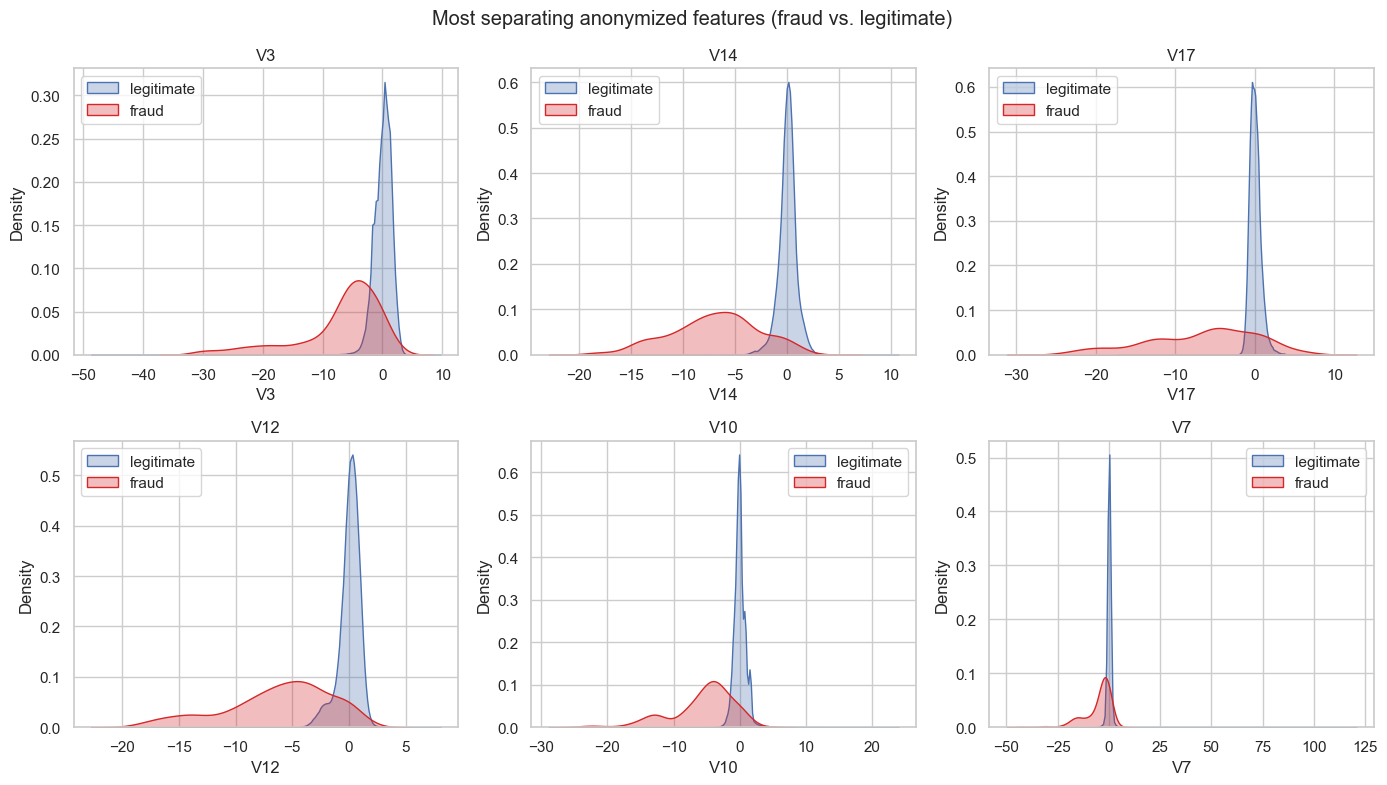

In [8]:
top_features = separation.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, top_features):
    sns.kdeplot(df.loc[df.Class == 0, col], ax=ax, label="legitimate", fill=True, alpha=0.3)
    sns.kdeplot(df.loc[df.Class == 1, col], ax=ax, label="fraud", fill=True, alpha=0.3, color="tab:red")
    ax.set_title(col)
    ax.legend()
plt.suptitle("Most separating anonymized features (fraud vs. legitimate)")
plt.tight_layout()
plt.savefig("../reports/figures/top_v_features_by_class.png", dpi=150)
plt.show()

Several `V` features (`V3`, `V14`, `V17`, `V12`, `V10`, `V7` in this
dataset) show visibly different distributions between fraud and legitimate
transactions — their density peaks are clearly shifted apart, not just
overlapping noise. This is encouraging: even without knowing what these
components originally represented, they carry real predictive signal we can
exploit. Tree-based models in particular won't need us to hand-pick these;
they'll discover the useful splits on their own.

## 5. Data quality checks

In [9]:
print("Missing values per column:\n", df.isna().sum().sum())
print("\nFully duplicated rows:", df.duplicated().sum())

Missing values per column:
 0



Fully duplicated rows: 1081


No missing values. There are 1,081 fully duplicated rows (~0.4% of the data) —
we'll drop these in Stage 2 before splitting train/test, since duplicates can
leak information across the split and inflate apparent performance.

## 6. Summary — what this means for modeling

- **Severe class imbalance (0.17% fraud)** is the central challenge. Accuracy
  is meaningless here; we'll evaluate with precision, recall, F1, PR-AUC, and
  ROC-AUC instead, and likely care most about **recall at an acceptable
  precision** — missing fraud is usually costlier than a false alarm.
- **`Amount` needs scaling** before use in distance- or gradient-based models;
  the `V` features are already on a comparable scale from PCA.
- **Several `V` features show strong class separation** (e.g. `V3`, `V14`,
  `V17`), suggesting models should be able to learn a useful decision boundary
  even though the features are anonymized.
- **No missing data**, but there are 1,081 duplicate rows that should be
  dropped before splitting train/test to avoid leakage.
- Given the imbalance, train/test (and cross-validation) splits should be
  **stratified** by `Class` so each split preserves the same fraud rate.

**Next up (`02_baseline.ipynb`):** build a logistic regression baseline with
proper scaling and a stratified split, and establish the metrics we'll track
across every later model.